In [3]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('student_admission_record_dirty.csv')

In [4]:
# 1. Tampilkan rata-rata, standar deviasi, nilai minimum, nilai maksimum, Q1, Q2, dan Q3 dari attribute bertipe angka.
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols].describe() 

,Age,Admission Test Score,High School Percentage
count,147.000000,146.000000,146.000000
mean,19.680272,77.657534,75.684726
std,4.540512,16.855343,17.368014
min,-1.000000,-5.000000,-10.000000
25%,18.000000,68.250000,65.052500
50%,20.000000,79.000000,77.545000
75%,22.000000,89.000000,88.312500
max,24.000000,150.000000,110.500000


## Usia:
1. Nilai minimum -1.0 tahun memang tidak mungkin secara logis
2. Standar deviasi 4.54 mengindikasikan variasi yang tinggi
3. Median 20 tahun masuk akal untuk mahasiswa baru
4. Rentang interkuartil 18-22 tahun menunjukkan distribusi normal 

## Admission Test Score:
1. Nilai minimum -5.0 menunjukkan masalah kualitas data
2. Standar deviasi 16.86 menunjukkan variabilitas wajar
3. Nilai maksimum 150 mengindikasikan performa exceptional atau skala tidak standar
4. Median (79) mendekati mean (77.66) menunjukkan distribusi relatif normal 

## High School Percentage:
1. Nilai minimum -10.0% dan maksimum 110.5% tidak valid secara konseptual 
2. Standar deviasi tinggi (17.37) mengkonfirmasi outlier
3. Median lebih tinggi dari Q1 menunjukkan distribusi normal di bagian tengah 

In [5]:
# 2. Tampilkan 10 record pertama dari dataset dengan attribute bertipe angka.
df[numeric_cols].head(10)

,Age,Admission Test Score,High School Percentage
0,24.0,50.0,68.90
1,21.0,99.0,60.73
2,17.0,89.0,NaN
3,17.0,55.0,85.29
4,20.0,65.0,61.13
5,23.0,NaN,NaN
6,18.0,NaN,97.31
7,20.0,82.0,55.67
8,17.0,64.0,NaN
9,18.0,53.0,98.98


#### 1. Terdapat nilai kosong (NaN) pada beberapa record. Dari 10 data yang ditampilkan, 4 di antaranya memiliki data yang hilang. Kolom High School Percentage paling banyak mengalami kekosongan data, diikuti oleh kolom Admission Test Score. Hal ini mengindikasikan masalah dalam proses pengumpulan atau input data.
#### 2. Summary statistik sebelumnya mengungkap adanya nilai-nilai tidak valid seperti usia -1 tahun, nilai tes -5, dan persentase SMA -10% hingga 110.5%. Ini menunjukkan bahwa masalah data yang lebih serius terdapat pada record-record di luar sample ini

In [6]:
# 3. Tampilkan informasi jumlah record, jumlah attribute, nama attribute, jumlah attribute dengan tipe angka.
total_records = df.shape[0]
total_attributes = df.shape[1]
attribute_names = df.columns.tolist()
numeric_count = len(numeric_cols)

print(f"Jumlah record: {total_records}")
print(f"Jumlah atribut: {total_attributes}")
print(f"Nama atribut: {attribute_names}")
print(f"Jumlah atribut numerik: {numeric_count}")

Jumlah record: 157
Jumlah atribut: 7
Nama atribut: ['Name', 'Age', 'Gender', 'Admission Test Score', 'High School Percentage', 'City', 'Admission Status']
Jumlah atribut numerik: 3


#### Dataset ini berisi data 157 mahasiswa dengan 7 karakteristik yang dicatat, dimana hanya 3 yang berupa data numerik, sedangkan 4 lainnya adalah data kategorikal atau teks.

In [7]:
# 4. Tampilkan jumlah label dari semua attribute yang bernilai object (contoh : Jenis Kelamin, Agama)
object_cols = df.select_dtypes(include='object').columns

print("Jumlah label unik untuk atribut kategori:")
for col in object_cols:
    print(f"{col}: {df[col].nunique()} label unik")

Jumlah label unik untuk atribut kategori:
Name: 64 label unik
Gender: 2 label unik
City: 7 label unik
Admission Status: 2 label unik


#### 1. Ada 64 nama unik dari 157 record
#### 2. Hanya ada 2 jenis kelamin (mungkin Male/Female atau L/P)
#### 3. Mahasiswa berasal dari 7 kota berbeda
#### 4. Hanya ada 2 status penerimaan (mungkin Accepted/Rejected atau Yes/No)

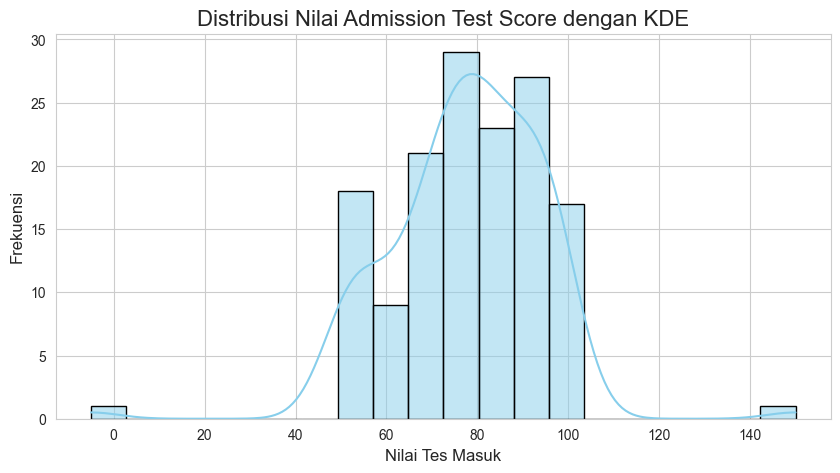

In [13]:
# Visualisasikan dataset dengan histogram
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x='Admission Test Score',
    kde=True, 
    bins=20,
    color='skyblue',
    edgecolor='black'
)

# Tambahkan judul dan label
plt.title('Distribusi Nilai Admission Test Score', fontsize=16)
plt.xlabel('Nilai Tes Masuk', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()

#### Berdasarkan histogram Distribusi Nilai Admission Test Score, dapat dijelaskan bahwa sebaran nilai tes masuk mahasiswa menunjukkan pola yang mendekati distribusi normal dengan puncaknya terletak pada kisaran nilai 70-80. Mayoritas mahasiswa memperoleh nilai antara 60 hingga 90, dengan konsentrasi tertinggi mencapai sekitar 25-30 mahasiswa pada rentang nilai tertentu. Distribusi ini terlihat cukup simetris dengan ekor yang memanjang di kedua sisi, mengindikasikan adanya variasi kemampuan mahasiswa dari yang sangat rendah hingga sangat tinggi.

#### Histogram mengungkapkan bahwa tes masuk berhasil menangkap keragaman kemampuan akademik calon mahasiswa. Meskipun sebagian besar terkonsentrasi di level menengah, terdapat beberapa mahasiswa yang menunjukkan performa exceptional dengan nilai di atas 100, sementara sebagian kecil lainnya memperoleh nilai di bawah 40. Pola distribusi yang relatif mulus tanpa celah yang signifikan menunjukkan bahwa instrumen tes tersebut cukup efektif dalam membedakan tingkat kemampuan peserta.

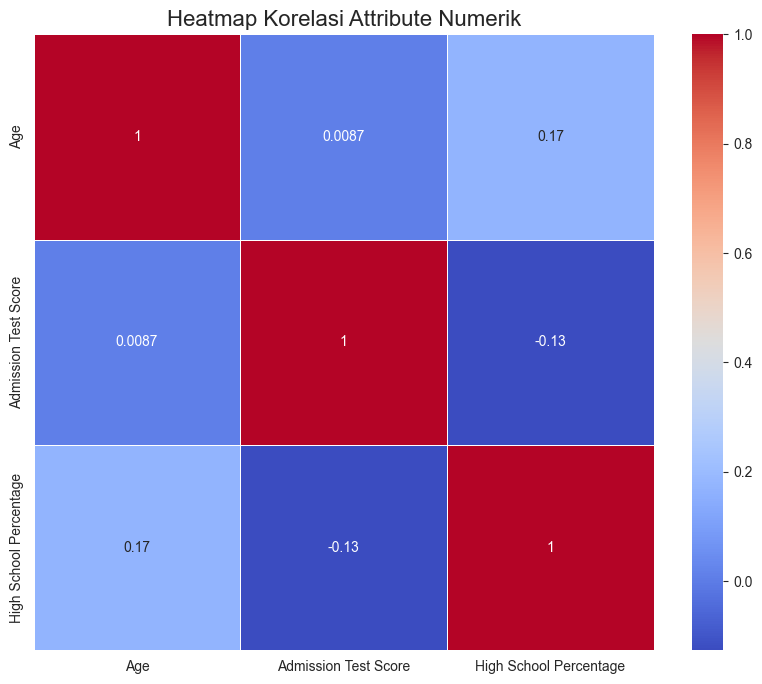

In [14]:
# 6. Tampilkan korelasi dataset menggunakan heatmap.
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Attribute Numerik', fontsize=16)
plt.show()

## Korelasi Sangat Lemah:

1. Age dan Test Score: 0.0087 → hampir nol, tidak ada hubungan
2. Age dan HS Percentage: 0.17 → hubungan positif lemah
3. Test Score dan HS Percentage: -0.13 → hubungan negatif lemah

### Test Score dan HS Percentage seharusnya berhubungan positif (nilai SMA tinggi → test score tinggi), tapi di data ini malah negatif.
### Tidak ada hubungan kuat antara ketiga variabel ini.

# Kesimpulan Analisis Data

1. Dataset ini memiliki total 157 record dan 7 atribut. Dari jumlah atribut tersebut, 3 di antaranya bertipe angka (numerik), sementara 4 sisanya bertipe objek (kategorikal).
2. Data memiliki beberapa nilai yang tidak valid atau logis. Terdapat nilai negatif pada kolom Age, Admission Test Score, dan High School Percentage. Hal ini menunjukkan bahwa data cleaning (pembersihan data) diperlukan sebelum melakukan analisis lebih lanjut. Rata-rata (mean) dan median (50%) dari Admission Test Score dan High School Percentage menunjukkan bahwa sebagian besar data terkonsentrasi di sekitar nilai tengah.

## Distribusi Data (Histogram):
1. Age: Distribusi usia menunjukkan sebaran yang cenderung miring ke kanan (skewed right). Ini berarti sebagian besar mahasiswa berusia muda.
2. Admission Test Score dan High School Percentage: Kedua atribut ini menunjukkan distribusi yang cenderung normal atau menyerupai bentuk lonceng, dengan sebagian besar data terkonsentrasi di sekitar nilai rata-ratanya.

## Korelasi Dataset (Heatmap): 
1. Berdasarkan visualisasi heatmap, hubungan antar atribut numerik sangat lemah. Nilai korelasi terkuat adalah 0.17 antara Age dan High School Percentage. Ini mengindikasikan bahwa tidak ada hubungan linear yang signifikan antara usia, skor tes, dan persentase nilai sekolah.